# Tugas Praktikum 2: Praproses Data
Dataset: House Prices - Advanced Regression Techniques (Kaggle), berisi informasi harga rumah beserta atribut seperti ukuran, tahun dibangun, dan kondisi rumah.

Link: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv


## 1. Unduh dan Import Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Jumlah baris dan kolom

df.shape
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 1460
Jumlah kolom: 81


In [4]:
# Info dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 2. Pembersihan Data

In [5]:
# Cek jumlah dan presentase missing value

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Jumlah Hilang': missing,
    'Persentase (%)': missing_pct
})
missing_table = missing_table[missing_table['Jumlah Hilang'] > 0].sort_values('Persentase (%)', ascending=False)
print(missing_table)

              Jumlah Hilang  Persentase (%)
PoolQC                 1453           99.52
MiscFeature            1406           96.30
Alley                  1369           93.77
Fence                  1179           80.75
MasVnrType              872           59.73
FireplaceQu             690           47.26
LotFrontage             259           17.74
GarageType               81            5.55
GarageYrBlt              81            5.55
GarageFinish             81            5.55
GarageQual               81            5.55
GarageCond               81            5.55
BsmtExposure             38            2.60
BsmtFinType2             38            2.60
BsmtQual                 37            2.53
BsmtCond                 37            2.53
BsmtFinType1             37            2.53
MasVnrArea                8            0.55
Electrical                1            0.07


In [6]:
# Hapus kolom dengan missing value > 50%

cols_to_drop = missing_table[missing_table['Persentase (%)'] > 50].index.tolist()
print("Kolom yang dihapus (missing > 50%):", cols_to_drop)

Kolom yang dihapus (missing > 50%): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


In [7]:
df = df.drop(columns=cols_to_drop)
print("Ukuran dataset setelah penghapusan kolom:", df.shape)

Ukuran dataset setelah penghapusan kolom: (1460, 76)


In [8]:
# Tangani nilai hilang yang tersisa

none_cat_cols = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                  'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for c in none_cat_cols:
    df[c] = df[c].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# LotFrontage diisi median per Neighborhood, bukan median global karena panjang lot sangat dipengaruhi lokasi/lingkungan rumah

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("Total missing value tersisa:", df.isnull().sum().sum())
print("Ukuran dataset setelah pembersihan:", df.shape)

Total missing value tersisa: 0
Ukuran dataset setelah pembersihan: (1460, 76)


## 3. Deteksi dan Penanganan Outlier

In [9]:
# Jumlah Atribut Numerik

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Id')
print(f"Jumlah atribut numerik: {len(num_cols)}")

Jumlah atribut numerik: 37


In [10]:
# Jumlah Outlier (IQR) — Sebelum Ditangani

hasil_outlier = []
for kolom in num_cols:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = ((df[kolom] < batas_bawah) | (df[kolom] > batas_atas)).sum()
    hasil_outlier.append([kolom, jumlah_outlier])

outlier_df = pd.DataFrame(hasil_outlier, columns=['Atribut', 'Jumlah Outlier'])
outlier_df = outlier_df[outlier_df['Jumlah Outlier'] > 0].sort_values('Jumlah Outlier', ascending=False)
outlier_df.set_index('Atribut', inplace=True)
print(outlier_df)

               Jumlah Outlier
Atribut                      
EnclosedPorch             208
BsmtFinSF2                167
OverallCond               125
ScreenPorch               116
MSSubClass                103
MasVnrArea                 98
LotFrontage                93
BsmtHalfBath               82
GarageYrBlt                81
OpenPorchSF                77
LotArea                    69
KitchenAbvGr               68
TotalBsmtSF                61
SalePrice                  61
MiscVal                    52
BedroomAbvGr               35
WoodDeckSF                 32
GrLivArea                  31
TotRmsAbvGrd               30
BsmtUnfSF                  29
LowQualFinSF               26
3SsnPorch                  24
GarageArea                 21
1stFlrSF                   20
YearBuilt                   7
PoolArea                    7
BsmtFinSF1                  7
GarageCars                  5
Fireplaces                  5
OverallQual                 2
2ndFlrSF                    2
BsmtFullBa

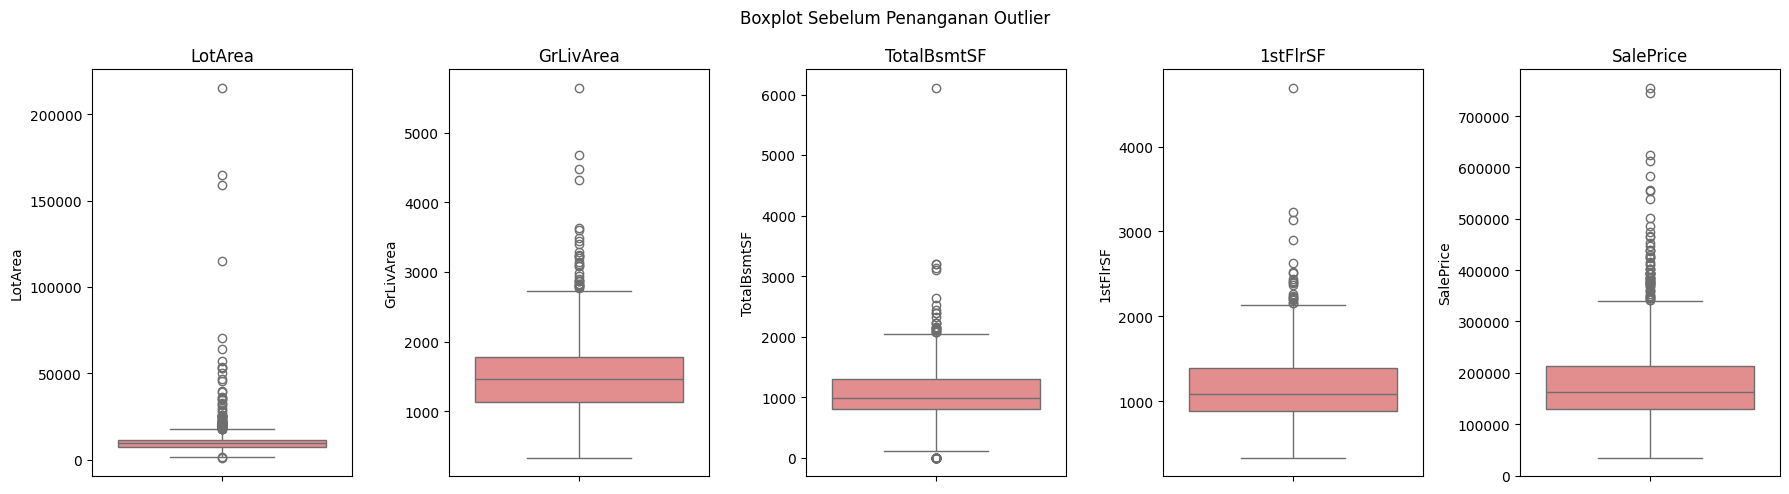

In [11]:
# Boxplot Sebelum Outlier Ditangani

num_check = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'SalePrice']

fig, axes = plt.subplots(1, len(num_check), figsize=(18, 5))
for ax, col in zip(axes, num_check):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.suptitle('Boxplot Sebelum Penanganan Outlier')
plt.tight_layout()
plt.show()

In [12]:
# Penanganan Outlier: Disesuaikan (Capping)

nunique = df[num_cols].nunique()
kolom_kontinu = nunique[nunique > 25].index.tolist()

def hitung_outlier(data, kolom):
    Q1, Q3 = data[kolom].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((data[kolom] < lo) | (data[kolom] > hi)).sum(), lo, hi

for k in kolom_kontinu:
    n, lo, hi = hitung_outlier(df, k)
    df[k] = df[k].clip(lower=lo, upper=hi)

print("Jumlah baris setelah penanganan outlier:", df.shape[0])

Jumlah baris setelah penanganan outlier: 1460


In [13]:
# Jumlah Outlier (IQR) — Setelah Ditangani

hasil_outlier_sesudah = []
for kolom in num_cols:
    n, lo, hi = hitung_outlier(df, kolom)
    hasil_outlier_sesudah.append([kolom, n])

outlier_df_sesudah = pd.DataFrame(hasil_outlier_sesudah, columns=['Atribut', 'Jumlah Outlier'])
outlier_df_sesudah = outlier_df_sesudah[outlier_df_sesudah['Jumlah Outlier'] > 0].sort_values('Jumlah Outlier', ascending=False)
outlier_df_sesudah.set_index('Atribut', inplace=True)
print(outlier_df_sesudah)

              Jumlah Outlier
Atribut                     
OverallCond              125
MSSubClass               103
BsmtHalfBath              82
KitchenAbvGr              68
MiscVal                   52
BedroomAbvGr              35
TotRmsAbvGrd              30
LowQualFinSF              26
3SsnPorch                 24
PoolArea                   7
Fireplaces                 5
GarageCars                 5
OverallQual                2
BsmtFullBath               1


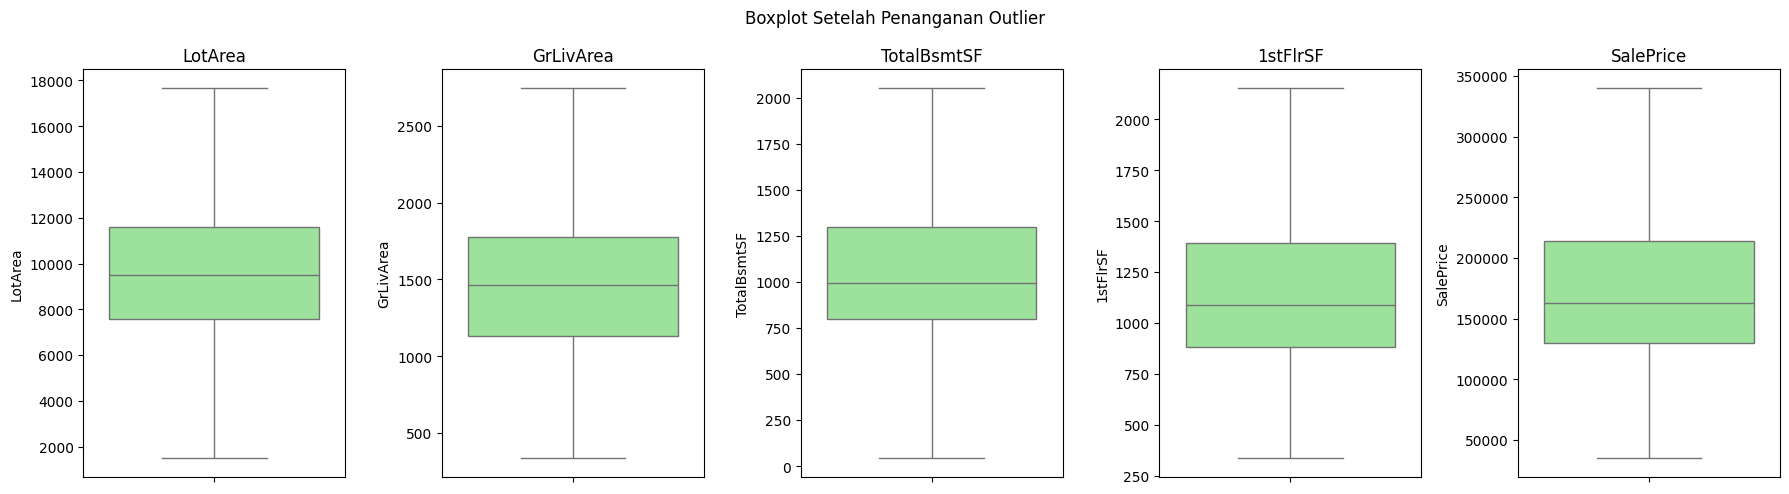

In [14]:
# Boxplot Setelah Penanganan Outlier

fig, axes = plt.subplots(1, len(num_check), figsize=(18, 5))
for ax, col in zip(axes, num_check):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.suptitle('Boxplot Setelah Penanganan Outlier')
plt.tight_layout()
plt.show()

In [15]:
# Simpan Dataset Hasil Cleaning ke CSV

df.to_csv("5054251050_Kadek Nathania Gavrila Astika_Tugas_Praproses_Data.csv", index=False)
print("Dataset tersimpan, ukuran:", df.shape)

Dataset tersimpan, ukuran: (1460, 76)


## 4. Transformasi Data

In [16]:
# Pisahkan target dan identifier

target = df['SalePrice'].reset_index(drop=True)
ids = df['Id'].reset_index(drop=True)

df_features = df.drop(columns=['Id', 'SalePrice']).reset_index(drop=True)

numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_features.select_dtypes(include=['object']).columns.tolist()

print(f"Jumlah atribut numerik: {len(numeric_features)}")
print(f"Jumlah atribut kategorikal: {len(categorical_features)}")

Jumlah atribut numerik: 36
Jumlah atribut kategorikal: 38


In [17]:
scaler = StandardScaler()
df_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(df_features[numeric_features]),
    columns=numeric_features
)

df_scaled_numeric.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.073375,-0.249286,-0.333244,0.651479,-0.517200,1.053246,0.878668,0.795643,0.614224,0.0,...,0.373509,-0.787243,0.350520,0.0,-0.116339,0.0,-0.068692,-0.087688,-1.599111,0.138777
1,-0.872563,0.583251,-0.013189,-0.071836,2.179628,0.156179,-0.429577,-0.667353,1.242296,0.0,...,-0.051541,1.768105,-0.811747,0.0,-0.116339,0.0,-0.068692,-0.087688,-0.489110,-0.614439
2,0.073375,-0.082779,0.446022,0.651479,-0.517200,0.986797,0.830215,0.541858,0.106224,0.0,...,0.663315,-0.787243,-0.011497,0.0,-0.116339,0.0,-0.068692,-0.087688,0.990891,0.138777
3,0.309859,-0.526798,-0.027104,0.651479,-0.517200,-1.870528,-0.720298,-0.667353,-0.517230,0.0,...,0.827539,-0.787243,-0.144872,0.0,-0.116339,0.0,-0.068692,-0.087688,-1.599111,-1.367655
4,0.073375,0.805261,1.283733,1.374795,-0.517200,0.953572,0.733308,1.945140,0.496460,0.0,...,1.764579,0.859156,0.788753,0.0,-0.116339,0.0,-0.068692,-0.087688,2.100892,0.138777


In [18]:
# Cek statistik deskriptif setelah standarisasi (mean mendekati 0, std mendekati 1)

df_scaled_numeric.describe().loc[['mean', 'std']].T.head(10)

,mean,std
MSSubClass,-8.455945e-17,1.000343
LotFrontage,1.812857e-16,1.000343
LotArea,5.535907e-17,1.000343
OverallQual,1.387018e-16,1.000343
OverallCond,3.540547e-16,1.000343
YearBuilt,1.178966e-15,1.000343
YearRemodAdd,4.496860e-15,1.000343
MasVnrArea,9.733462e-18,1.000343
BsmtFinSF1,2.676702e-17,1.000343
BsmtFinSF2,0.000000e+00,0.000000


In [19]:
# Encoding Atribut Kategorikal (One-Hot Encoding)

df_encoded_categorical = pd.get_dummies(df_features[categorical_features], drop_first=True)
print("Shape atribut kategorikal sebelum encoding:", df_features[categorical_features].shape)
print("Shape atribut kategorikal setelah one-hot encoding:", df_encoded_categorical.shape)
df_encoded_categorical.head()

Shape atribut kategorikal sebelum encoding: (1460, 38)
Shape atribut kategorikal setelah one-hot encoding: (1460, 207)


,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [20]:
# Gabungkan atribut numerik yang sudah distandarisasi dengan atribut kategorikal yang sudah di-encode

df_transformed = pd.concat([df_scaled_numeric, df_encoded_categorical], axis=1)
print("Shape dataset setelah transformasi (sebelum reduksi dimensi):", df_transformed.shape)

Shape dataset setelah transformasi (sebelum reduksi dimensi): (1460, 243)


In [21]:
df_transformed.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073375,-0.249286,-0.333244,0.651479,-0.517200,1.053246,0.878668,0.795643,0.614224,0.0,...,False,False,False,False,True,False,False,False,True,False
1,-0.872563,0.583251,-0.013189,-0.071836,2.179628,0.156179,-0.429577,-0.667353,1.242296,0.0,...,False,False,False,False,True,False,False,False,True,False
2,0.073375,-0.082779,0.446022,0.651479,-0.517200,0.986797,0.830215,0.541858,0.106224,0.0,...,False,False,False,False,True,False,False,False,True,False
3,0.309859,-0.526798,-0.027104,0.651479,-0.517200,-1.870528,-0.720298,-0.667353,-0.517230,0.0,...,False,False,False,False,True,False,False,False,False,False
4,0.073375,0.805261,1.283733,1.374795,-0.517200,0.953572,0.733308,1.945140,0.496460,0.0,...,False,False,False,False,True,False,False,False,True,False


## 5. Reduksi Dimensi

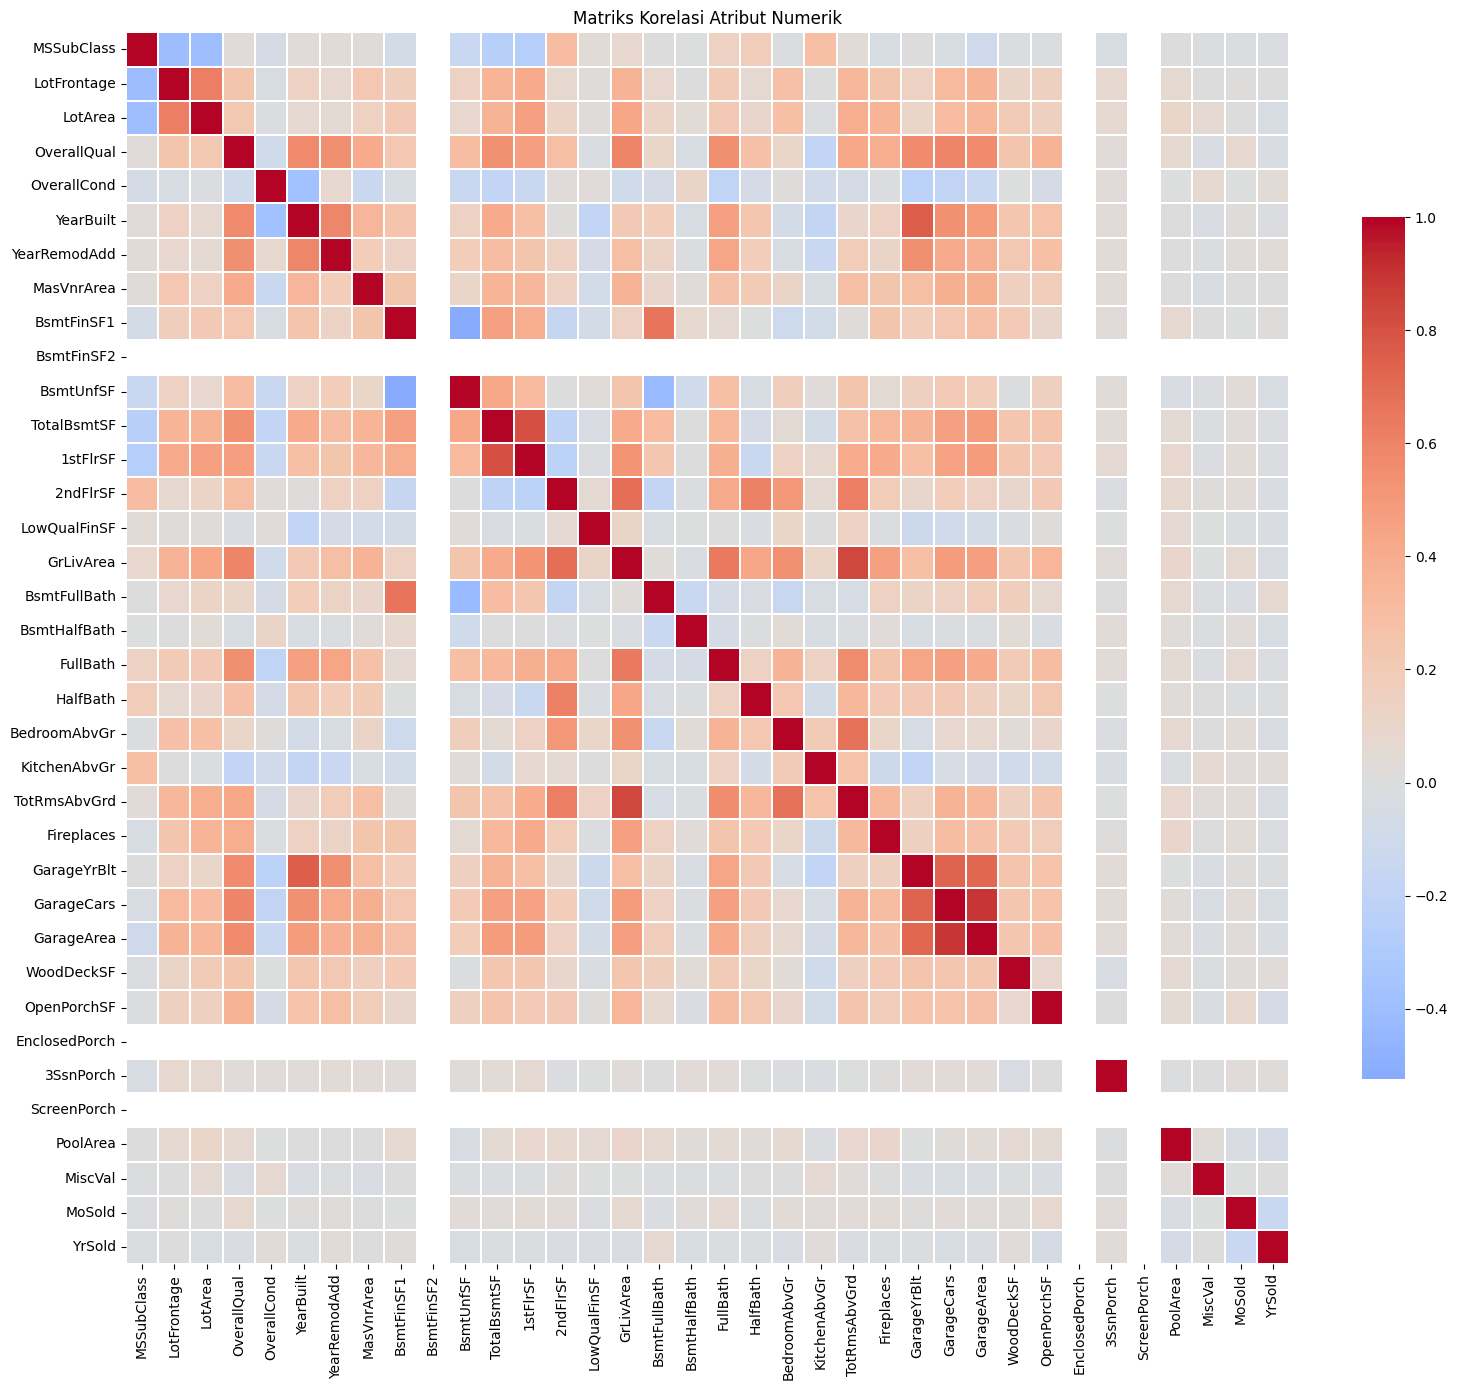

In [22]:
# Analisis Korelasi

corr_matrix = df_scaled_numeric.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Matriks Korelasi Atribut Numerik')
plt.tight_layout()
plt.show()

In [23]:
# Identifikasi pasangan atribut dengan korelasi absolut > 0.8

threshold = 0.8
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

corr_pairs_df = pd.DataFrame(corr_pairs, columns=['Atribut_1', 'Atribut_2', 'Korelasi'])
corr_pairs_df = corr_pairs_df.sort_values('Korelasi', key=abs, ascending=False)
corr_pairs_df


,Atribut_1,Atribut_2,Korelasi
2,GarageArea,GarageCars,0.893
1,TotRmsAbvGrd,GrLivArea,0.836
0,1stFlrSF,TotalBsmtSF,0.807


In [24]:
# Buang salah satu atribut dari tiap pasangan yang sangat berkorelasi

cols_to_drop_corr = set()
for a1, a2, val in corr_pairs:
    cols_to_drop_corr.add(a2)

cols_to_drop_corr = list(cols_to_drop_corr)
print("Atribut yang dibuang karena korelasi tinggi:")
print(cols_to_drop_corr)

df_scaled_numeric_reduced = df_scaled_numeric.drop(columns=cols_to_drop_corr)
print("\nShape atribut numerik sebelum reduksi korelasi:", df_scaled_numeric.shape)
print("Shape atribut numerik setelah reduksi korelasi:", df_scaled_numeric_reduced.shape)


Atribut yang dibuang karena korelasi tinggi:
['GarageCars', 'TotalBsmtSF', 'GrLivArea']

Shape atribut numerik sebelum reduksi korelasi: (1460, 36)
Shape atribut numerik setelah reduksi korelasi: (1460, 33)


In [25]:
# Susun ulang dataset fitur akhir (numerik hasil reduksi korelasi + kategorikal ter-encoding)

df_final_features = pd.concat([df_scaled_numeric_reduced, df_encoded_categorical], axis=1)
print("Shape dataset akhir sebelum PCA:", df_final_features.shape)

Shape dataset akhir sebelum PCA: (1460, 240)


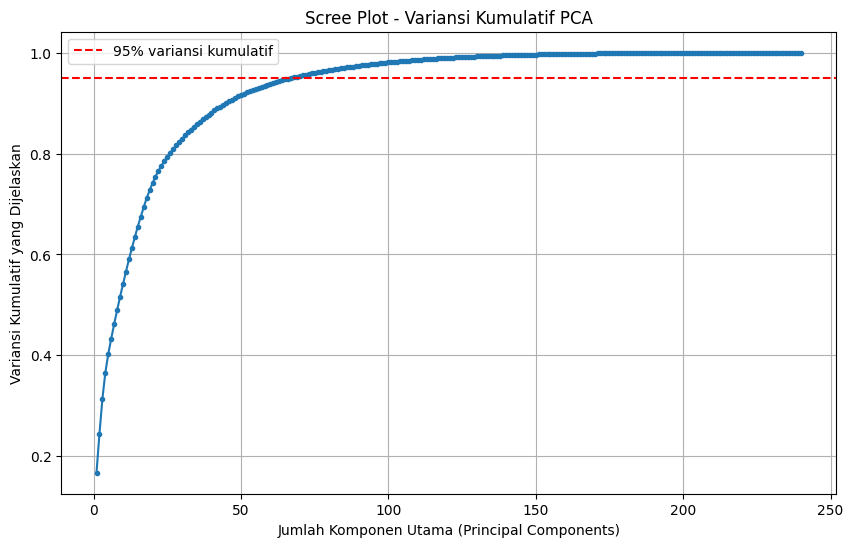

In [26]:
pca_full = PCA()
pca_full.fit(df_final_features)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='.', linestyle='-')
plt.axhline(0.95, color='red', linestyle='--', label='95% variansi kumulatif')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Variansi Kumulatif yang Dijelaskan')
plt.title('Scree Plot - Variansi Kumulatif PCA')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Tentukan jumlah komponen yang menjelaskan minimal 95% variansi

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Jumlah komponen utama untuk mencapai >=95% variansi kumulatif: {n_components_95}")
print(f"Dari total {df_final_features.shape[1]} atribut menjadi {n_components_95} komponen utama.")

Jumlah komponen utama untuk mencapai >=95% variansi kumulatif: 67
Dari total 240 atribut menjadi 67 komponen utama.


In [28]:
# Terapkan PCA final dengan jumlah komponen terpilih

pca_final = PCA(n_components=n_components_95)
principal_components = pca_final.fit_transform(df_final_features)

df_pca = pd.DataFrame(
    principal_components,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)

print("Shape dataset akhir setelah PCA:", df_pca.shape)
df_pca.head()

Shape dataset akhir setelah PCA: (1460, 67)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC58,PC59,PC60,PC61,PC62,PC63,PC64,PC65,PC66,PC67
0,2.332751,0.336883,-1.965202,-1.767942,0.160133,-1.796529,1.124945,-0.495410,-0.720500,-0.174165,...,-0.372842,0.101915,0.025280,0.223251,-0.042188,-0.155074,0.215197,0.058003,-0.146328,0.000720
1,-0.143740,-1.343964,1.689368,-0.382607,-1.690116,1.371038,-0.264204,3.052725,-0.258742,2.144589,...,-0.257865,0.237424,-0.266286,-0.033406,-0.322895,-0.185900,-0.367042,0.035013,0.077013,0.155225
2,2.766660,0.196876,-1.348691,-1.285754,-0.424426,-0.722993,-0.367052,-0.474757,-0.684565,-0.665804,...,-0.046264,0.075574,0.133742,0.096338,0.147844,0.032758,0.252371,0.180299,-0.295993,0.005237
3,-0.718544,0.731724,0.353664,-0.594347,-0.281038,0.272269,-0.325811,-1.227057,0.369292,0.133911,...,0.764572,0.086522,0.338725,0.591057,0.033679,0.093265,0.636704,0.957076,0.418845,0.137481
4,4.918093,1.136256,0.495499,-1.553894,-0.171910,-0.488456,-0.710878,0.012395,-0.902550,-1.076038,...,-0.281276,-0.017555,0.187970,-0.290869,-0.018470,0.068849,-0.205114,0.136648,0.066304,0.209986


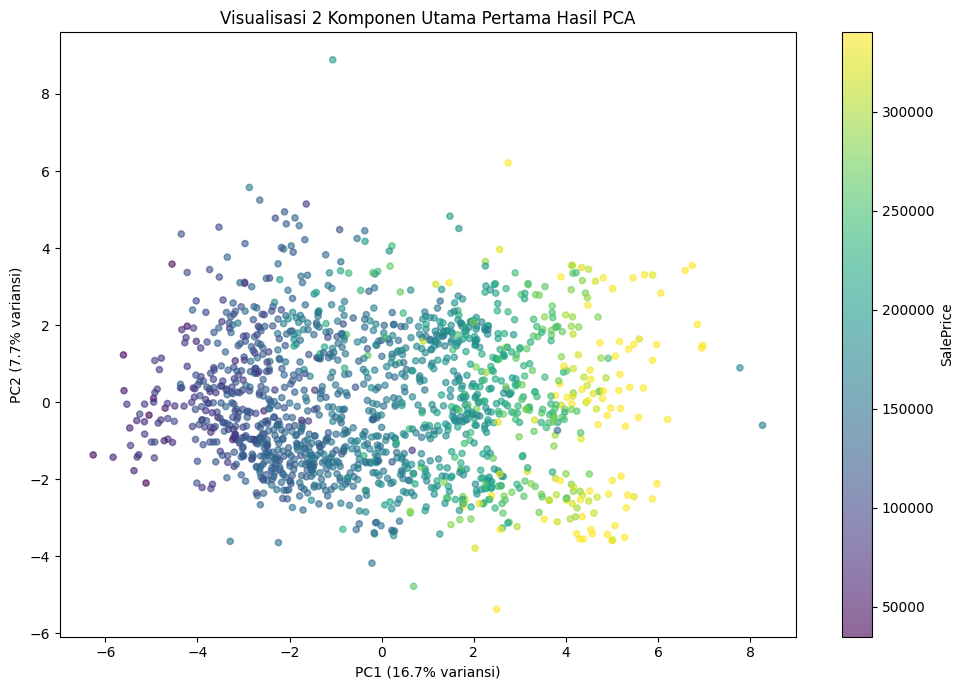

In [29]:
# Visualisasi 2 komponen utama pertama, diwarnai berdasarkan SalePrice

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=target, cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='SalePrice')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variansi)')
plt.title('Visualisasi 2 Komponen Utama Pertama Hasil PCA')
plt.tight_layout()
plt.show()

## Ringkasan Hasil Praproses

| Tahapan | Hasil |
|---|---|
| Dataset awal | 1460 baris x 81 kolom |
| Setelah hapus kolom missing > 50% | kolom `Alley`, `PoolQC`, `Fence`, `MiscFeature` (dan `FireplaceQu`/`LotFrontage` jika di atas ambang) dihapus |
| Setelah penanganan missing value | 0 nilai kosong tersisa |
| Setelah penanganan outlier | tidak ada baris dihapus; seluruh outlier di-capping (winsorizing) dengan batas IQR, jumlah baris tetap 1460 |
| Setelah transformasi | atribut numerik distandarisasi (StandardScaler), atribut kategorikal di-one-hot-encoding |
| Setelah reduksi korelasi | atribut dengan korelasi > 0.8 dikurangi salah satunya |
| Setelah PCA | dimensi akhir direduksi menjadi sejumlah komponen utama yang menjelaskan >= 95% variansi |

Dataset akhir (`df_pca`) sudah bersih, bebas dari nilai hilang, outlier telah ditangani, seluruh atribut telah ditransformasi (numerik + kategorikal), dan dimensinya telah direduksi sehingga siap digunakan untuk tahap pemodelan (modeling) selanjutnya.